## Chargement des données

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data/depression_dataset.csv")

## Exploration initiale

In [2]:
print(df.dtypes)
print(df.isnull().sum())

Name                                      object
Gender                                    object
Age                                        int64
City                                      object
Working Professional or Student           object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                           int64
Financial Stress                           int64
Family History of Mental Illness          object
Depression                                object
dtype: object
Name                                        0
Gender   

In [3]:
# on enlève les colonnes inutiles
df = df.drop(['Name', 'City'], axis=1)

for col in df.columns:
    print(df[col].value_counts())

Gender
Male      1333
Female    1223
Name: count, dtype: int64
Age
28    73
56    73
49    72
33    72
29    71
38    71
24    69
47    66
20    65
46    64
34    64
50    63
51    63
42    63
53    63
57    62
31    62
35    61
59    61
25    61
40    61
18    60
54    59
48    59
43    59
39    59
27    57
41    57
45    57
36    56
30    55
23    53
21    53
26    52
22    51
55    51
44    51
37    51
60    50
58    49
19    47
52    46
32    44
Name: count, dtype: int64
Working Professional or Student
Working Professional    2054
Student                  502
Name: count, dtype: int64
Profession
Teacher                   322
Content Writer            116
HR Manager                 84
Pharmacist                 75
Architect                  73
Consultant                 72
Business Analyst           71
Doctor                     66
Entrepreneur               63
Chef                       59
Chemist                    59
Lawyer                     48
Travel Consultant          46
Res

## Nettoyage et regroupement des catégories

In [4]:
# correction d'une faute de frappe dans Profession
df['Profession'] = df['Profession'].replace('Finanancial Analyst', 'Financial Analyst')
print(df['Profession'].value_counts())

Profession
Teacher                   322
Content Writer            116
HR Manager                 84
Pharmacist                 75
Financial Analyst          74
Architect                  73
Consultant                 72
Business Analyst           71
Doctor                     66
Entrepreneur               63
Chemist                    59
Chef                       59
Lawyer                     48
Travel Consultant          46
Researcher                 45
Educational Consultant     44
Manager                    42
Data Scientist             42
Judge                      42
Customer Support           41
Pilot                      39
Marketing Manager          39
Plumber                    35
Software Engineer          34
Electrician                33
Sales Executive            32
Digital Marketer           31
Civil Engineer             31
Mechanical Engineer        30
UX/UI Designer             26
Graphic Designer           26
Accountant                 17
Research Analyst           15

In [5]:
# regroupement des professions par secteur
profession = {
    'Teacher': 'Education', 'Educational Consultant': 'Education',
    'Researcher': 'Education', 'Research Analyst': 'Education',

    'Doctor': 'Sante', 'Pharmacist': 'Sante', 'Chemist': 'Sante',

    'Software Engineer': 'Tech', 'Data Scientist': 'Tech', 'UX/UI Designer': 'Tech',
    'Architect': 'Tech', 'Civil Engineer': 'Tech', 'Mechanical Engineer': 'Tech', 'Electrician': 'Tech',

    'HR Manager': 'Business', 'Business Analyst': 'Business', 'Manager': 'Business',
    'Consultant': 'Business', 'Entrepreneur': 'Business', 'Accountant': 'Business',
    'Investment Banker': 'Business', 'Financial Analyst': 'Business',

    'Lawyer': 'Droit', 'Judge': 'Droit',

    'Sales Executive': 'Service', 'Marketing Manager': 'Service', 'Digital Marketer': 'Service',
    'Travel Consultant': 'Service', 'Customer Support': 'Service', 'Content Writer': 'Service',
    'Graphic Designer': 'Service', 'Chef': 'Service', 'Plumber': 'Service', 'Pilot': 'Service',
}

df['Profession'] = df['Profession'].replace(profession)
print(df['Profession'].value_counts())

Profession
Service      464
Business     434
Education    426
Tech         269
Sante        200
Droit         90
Name: count, dtype: int64


In [6]:
# regroupement des diplômes par niveau
degree = {
    'Class 12': 'Bac',

    'B.Com': 'Licence', 'B.Ed': 'Licence', 'BCA': 'Licence', 'BBA': 'Licence',
    'BHM': 'Licence', 'BA': 'Licence', 'B.Arch': 'Licence', 'B.Pharm': 'Licence',
    'BSc': 'Licence', 'BE': 'Licence', 'LLB': 'Licence', 'B.Tech': 'Licence',

    'MBA': 'Master', 'MSc': 'Master', 'M.Tech': 'Master', 'M.Pharm': 'Master',
    'ME': 'Master', 'LLM': 'Master', 'MHM': 'Master', 'M.Ed': 'Master',
    'MA': 'Master', 'MBBS': 'Master', 'M.Com': 'Master', 'MCA': 'Master',

    'PhD': 'Doctorat', 'MD': 'Doctorat',
}

df['Degree'] = df['Degree'].replace(degree)
print(df['Degree'].value_counts())

Degree
Licence     1109
Master      1017
Bac          275
Doctorat     155
Name: count, dtype: int64


In [7]:
# conversion de la durée de sommeil en valeur numérique
sleep = {
    "Less than 5 hours": 4.5,
    "5-6 hours": 5.5,
    "7-8 hours": 7.5,
    "More than 8 hours": 8.5
}
df['Sleep Duration'] = df['Sleep Duration'].replace(sleep)
print(df['Sleep Duration'].value_counts())
print(df['Sleep Duration'].dtype)

df['Sleep Duration'] = df['Sleep Duration'].astype(float)

Sleep Duration
7.5    658
4.5    648
5.5    628
8.5    622
Name: count, dtype: int64
float64


/var/folders/r2/jbgbmmxn0bv3kybjmzk18rqm0000gn/T/ipykernel_31733/1385027332.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sleep Duration'] = df['Sleep Duration'].replace(sleep)


## Visualisation exploratoire : comparaison des populations et des features

Avant de séparer et d'encoder les données, on regarde comment les features se comparent entre les deux populations (étudiants / actifs) et selon le statut de dépression, pour identifier d'éventuelles différences ou déséquilibres importants.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# palette cohérente sur tout le notebook
COLOR_POP = {"Student": "#2a78d6", "Working Professional": "#eb6834"}
COLOR_DEP = {"No": "#1baf7a", "Yes": "#e34948"}


### Taux de dépression par population

Les deux populations n'ont pas du tout le même taux de dépression déclaré, ce qui justifie de les modéliser séparément (et explique pourquoi le jeu de test des employés est beaucoup plus déséquilibré que celui des étudiants).

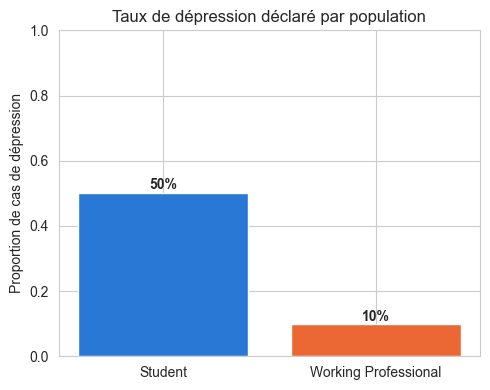

In [9]:
rate = df.groupby("Working Professional or Student")["Depression"].apply(lambda s: (s == "Yes").mean())

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(rate.index, rate.values, color=[COLOR_POP[i] for i in rate.index])
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center", fontweight="bold")
ax.set_ylabel("Proportion de cas de dépression")
ax.set_ylim(0, 1)
ax.set_title("Taux de dépression déclaré par population")
plt.tight_layout()
plt.show()


### Features communes aux deux populations

Comparaison de l'âge, du sommeil, du stress financier et des heures de travail/étude, selon la population et le statut de dépression.

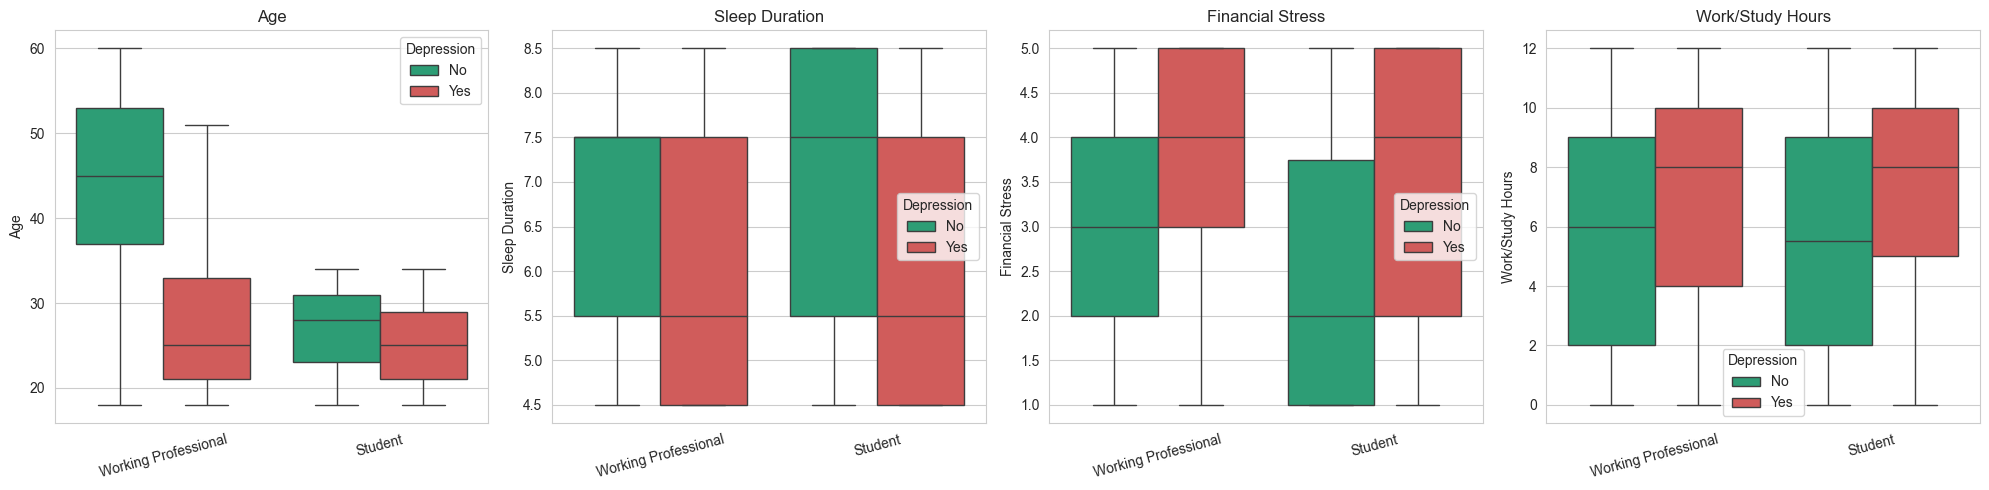

In [10]:
common_numeric = ["Age", "Sleep Duration", "Financial Stress", "Work/Study Hours"]

fig, axes = plt.subplots(1, len(common_numeric), figsize=(20, 5))
for ax, col in zip(axes, common_numeric):
    sns.boxplot(
        data=df, x="Working Professional or Student", y=col, hue="Depression",
        palette=COLOR_DEP, ax=ax,
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


### Features spécifiques à chaque population

La pression (académique / professionnelle) et la satisfaction (études / travail) ne concernent qu'une seule population chacune : on les compare selon le statut de dépression, séparément pour chaque groupe.

/var/folders/r2/jbgbmmxn0bv3kybjmzk18rqm0000gn/T/ipykernel_31733/4004463648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Working Professional or Student"] == "Student"],
/var/folders/r2/jbgbmmxn0bv3kybjmzk18rqm0000gn/T/ipykernel_31733/4004463648.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Working Professional or Student"] == "Working Professional"],


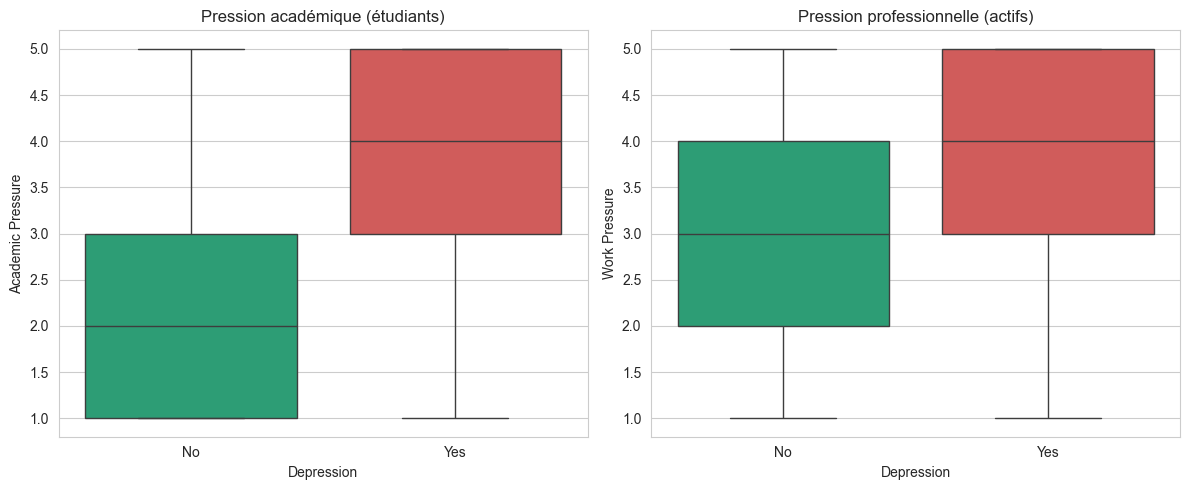

/var/folders/r2/jbgbmmxn0bv3kybjmzk18rqm0000gn/T/ipykernel_31733/4004463648.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Working Professional or Student"] == "Student"],
/var/folders/r2/jbgbmmxn0bv3kybjmzk18rqm0000gn/T/ipykernel_31733/4004463648.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Working Professional or Student"] == "Working Professional"],


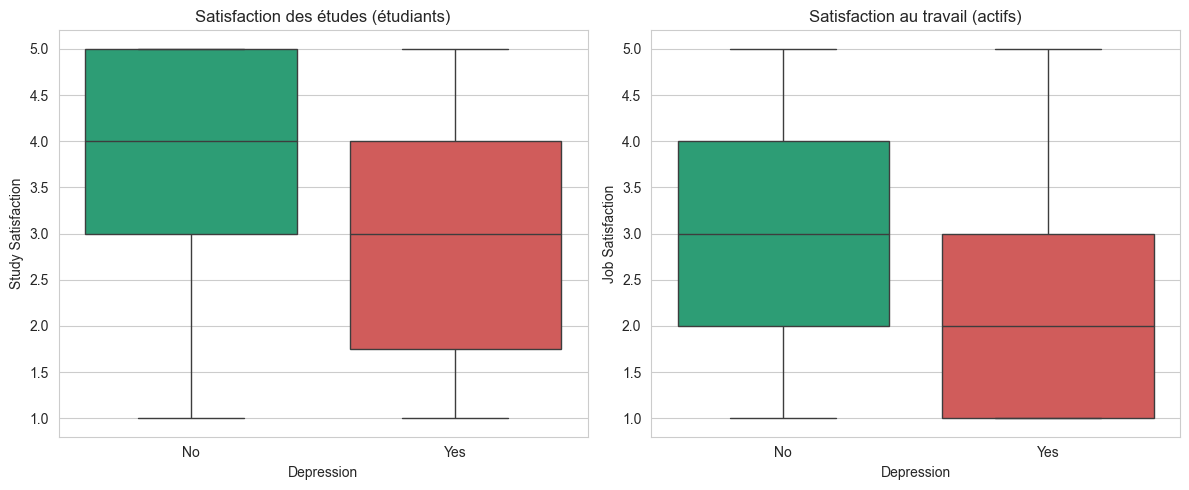

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df[df["Working Professional or Student"] == "Student"],
            x="Depression", y="Academic Pressure", palette=COLOR_DEP, ax=axes[0])
axes[0].set_title("Pression académique (étudiants)")

sns.boxplot(data=df[df["Working Professional or Student"] == "Working Professional"],
            x="Depression", y="Work Pressure", palette=COLOR_DEP, ax=axes[1])
axes[1].set_title("Pression professionnelle (actifs)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df[df["Working Professional or Student"] == "Student"],
            x="Depression", y="Study Satisfaction", palette=COLOR_DEP, ax=axes[0])
axes[0].set_title("Satisfaction des études (étudiants)")

sns.boxplot(data=df[df["Working Professional or Student"] == "Working Professional"],
            x="Depression", y="Job Satisfaction", palette=COLOR_DEP, ax=axes[1])
axes[1].set_title("Satisfaction au travail (actifs)")

plt.tight_layout()
plt.show()


### Variables catégorielles : habitudes et antécédents

Répartition des pensées suicidaires, des antécédents familiaux et des habitudes alimentaires, par population et statut de dépression.

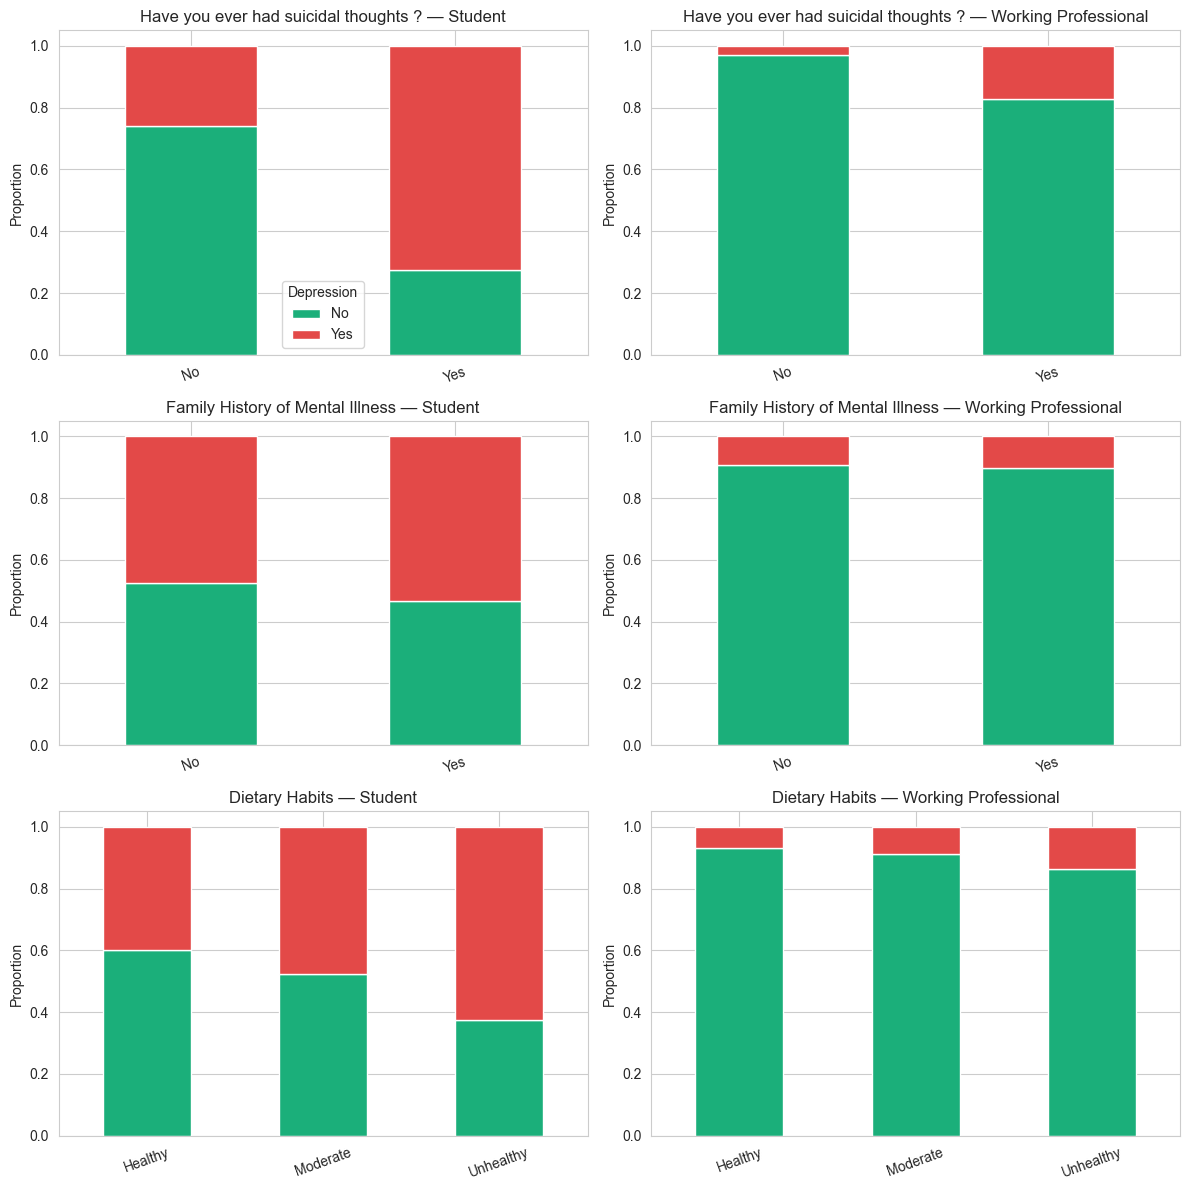

In [12]:
cat_features = ["Have you ever had suicidal thoughts ?", "Family History of Mental Illness", "Dietary Habits"]

fig, axes = plt.subplots(len(cat_features), 2, figsize=(12, 4 * len(cat_features)))
for row, col in enumerate(cat_features):
    for c, pop in enumerate(["Student", "Working Professional"]):
        sub = df[df["Working Professional or Student"] == pop]
        ct = pd.crosstab(sub[col], sub["Depression"], normalize="index")
        ct = ct[["No", "Yes"]]
        ct.plot(kind="bar", stacked=True, color=[COLOR_DEP["No"], COLOR_DEP["Yes"]], ax=axes[row, c], legend=(row == 0 and c == 0))
        axes[row, c].set_title(f"{col} — {pop}")
        axes[row, c].set_xlabel("")
        axes[row, c].set_ylabel("Proportion")
        axes[row, c].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


In [13]:
# encodage des variables catégorielles
le = LabelEncoder()
cols_binaires = ['Gender', 'Depression', 'Have you ever had suicidal thoughts ?',
                 'Family History of Mental Illness', 'Working Professional or Student',
                 'Degree', 'Profession', 'Dietary Habits']
for col in cols_binaires:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)

Gender                                     int64
Age                                        int64
Working Professional or Student            int64
Profession                                 int64
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                           float64
Dietary Habits                             int64
Degree                                     int64
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                           int64
Financial Stress                           int64
Family History of Mental Illness           int64
Depression                                 int64
dtype: object


## Séparation students / employees

In [14]:
# vérification des valeurs manquantes par groupe
print("Students:")
print(df[df['Working Professional or Student'] == 0][[
    'Academic Pressure', 'CGPA', 'Study Satisfaction']].isnull().sum())

print("Employees:")
print(df[df['Working Professional or Student'] == 1][[
    'Work Pressure', 'Job Satisfaction', 'Profession']].isnull().sum())

Students:
Academic Pressure     0
CGPA                  0
Study Satisfaction    0
dtype: int64
Employees:
Work Pressure       0
Job Satisfaction    0
Profession          0
dtype: int64


In [15]:
# séparation du dataset en deux : students et employees
df_students = df[df['Working Professional or Student'] == 0]
df_students = df_students.drop(['Work Pressure', 'Job Satisfaction', 'Profession', 'Working Professional or Student'], axis=1)

print(df_students.dtypes)
print(df_students.isnull().sum())

df_employee = df[df['Working Professional or Student'] == 1]
df_employee = df_employee.drop(['Academic Pressure', 'CGPA', 'Study Satisfaction', 'Working Professional or Student'], axis=1)

print(df_employee.dtypes)
print(df_employee.isnull().sum())

Gender                                     int64
Age                                        int64
Academic Pressure                        float64
CGPA                                     float64
Study Satisfaction                       float64
Sleep Duration                           float64
Dietary Habits                             int64
Degree                                     int64
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                           int64
Financial Stress                           int64
Family History of Mental Illness           int64
Depression                                 int64
dtype: object
Gender                                   0
Age                                      0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have 

### Corrélations avec Depression, students vs employees

Matrices de corrélation côte à côte (une fois les variables encodées) pour comparer visuellement quelles features sont liées à la dépression dans chaque population.

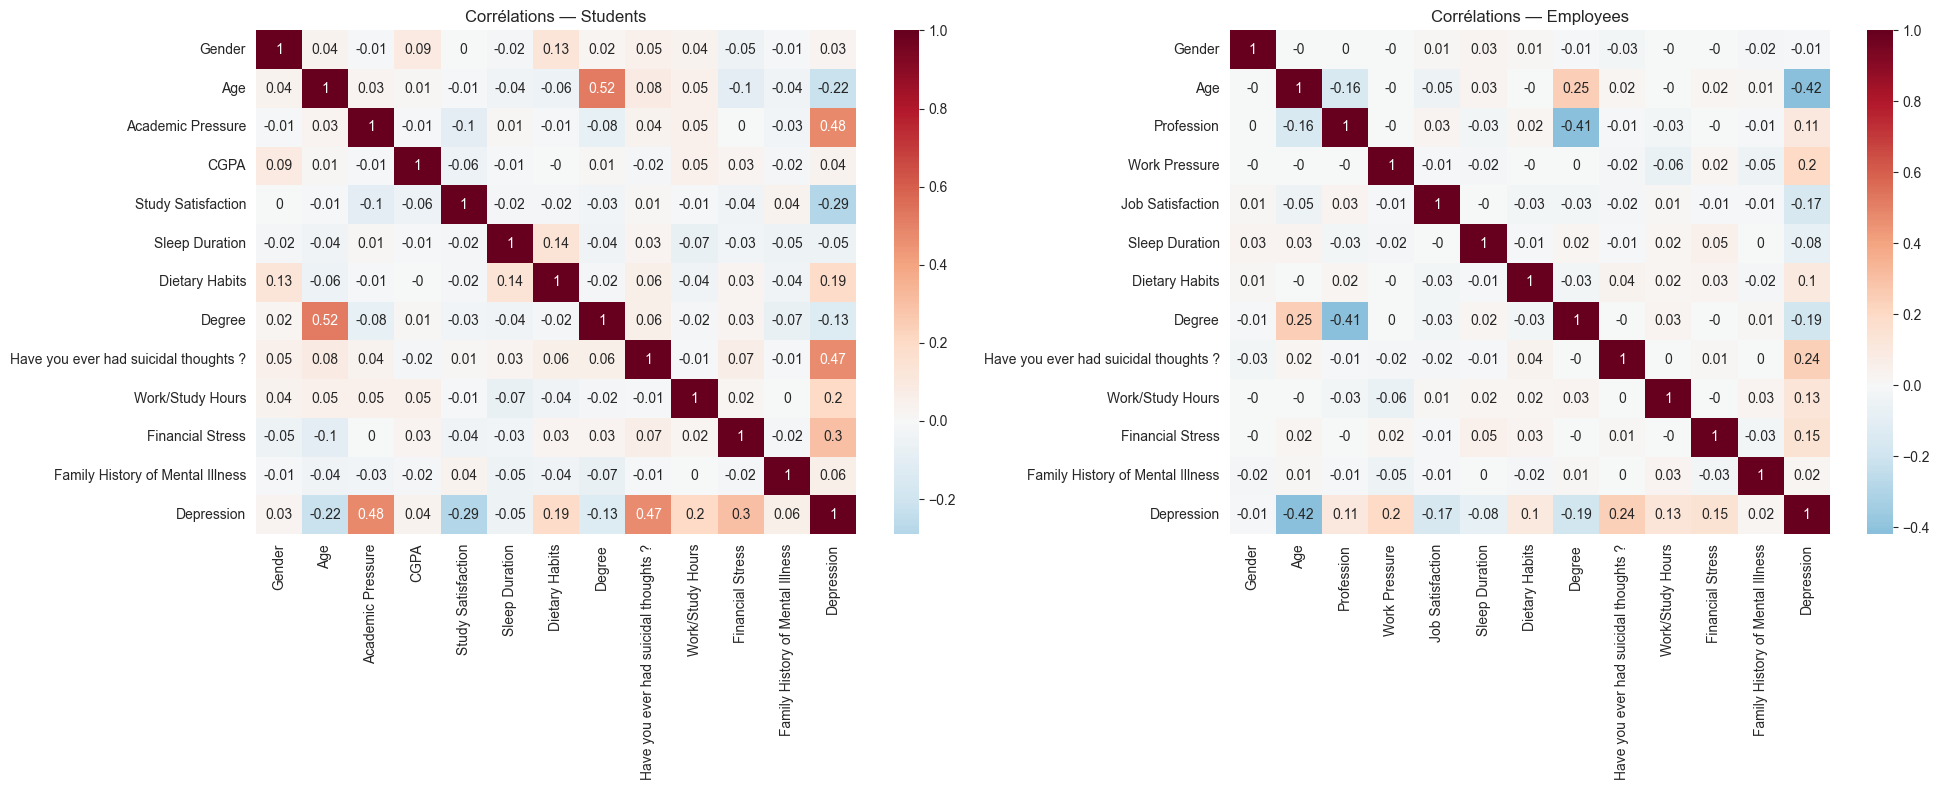

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(df_students.corr().round(2), annot=True, cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Corrélations — Students")

sns.heatmap(df_employee.corr().round(2), annot=True, cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Corrélations — Employees")

plt.tight_layout()
plt.show()


In [17]:
# sauvegarde des datasets nettoyés pour les notebooks/scripts suivants
df_students.to_csv("data/students_clean.csv", index=False)
df_employee.to_csv("data/employee_clean.csv", index=False)